# Group by: split-apply-combine

By “group by” we are referring to a process involving one or more of the following steps:

* **Splitting** the data into groups based on some criteria.
* **Applying** a function to each group independently.
* **Combining** the results into a data structure.

Out of these, the split step is the most straightforward. In the apply step, we might wish to do one of the following:

* **Aggregation**: compute a summary statistic (or statistics) for each group. Some examples:

  * Compute group sums or means.
  * Compute group sizes / counts.
* **Transformation**: perform some group-specific computations and return a like-indexed object. Some examples:

  * Standardize data (zscore) within a group.
  * Filling NAs within groups with a value derived from each group.
* **Filtration**: discard some groups, according to a group-wise computation that evaluates to True or False. Some examples:

  * Discard data that belong to groups with only a few members.
  * Filter out data based on the group sum or mean.


### Splitting an object into groups

In [1]:
import numpy as np
import pandas as pd

In [2]:
# The abstract definition of grouping is to provide a mapping of labels to group names. 
# To create a GroupBy object (more on what the GroupBy object is later), you may do the following:

speeds = pd.DataFrame(
    [
        ("bird", "Falconiformes", 389.0),
        ("bird", "Psittaciformes", 24.0),
        ("mammal", "Carnivora", 80.2),
        ("mammal", "Primates", np.nan),
        ("mammal", "Carnivora", 58),
    ],
    index=["falcon", "parrot", "lion", "monkey", "leopard"],
    columns=("class", "order", "max_speed"),
)

speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [3]:
grouped = speeds.groupby("class")
grouped

In [4]:
grouped = speeds.groupby(["class", "order"])
grouped

The mapping can be specified many different ways:

* A Python function, to be called on each of the index labels.
* A list or NumPy array of the same length as the index.
* A dict or `Series`, providing a `label -> group name` mapping.
* For `DataFrame` objects, a string indicating either a column name or an index level name to be used to group.
* A list of any of the above things.


In [5]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)

In [6]:
df

,A,B,C,D
0,foo,one,-1.013053,0.143497
1,bar,one,1.329097,0.405837
2,foo,two,-1.008103,0.129290
3,bar,three,-1.309196,-1.112608
4,foo,two,-0.672255,0.750958
5,bar,two,-1.095771,0.535120
6,foo,one,0.128034,0.525644
7,foo,three,1.918012,-0.757675


In [7]:
# On a DataFrame, we obtain a GroupBy object by calling groupby(). 
# This method returns a pandas.api.typing.DataFrameGroupBy instance. 
# We could naturally group by either the A or B columns, or both:

grouped = df.groupby("A")
grouped = df.groupby("B")
grouped = df.groupby(["A", "B"])

In [8]:
def get_letter_type(letter):
    if letter.lower() in 'aeiou':
        return 'vowel'
    else:
        return 'consonant'


grouped = df.T.groupby(get_letter_type)

pandas `Index` objects support duplicate values. If a non-unique index is used as the group key in a groupby operation, all values for the same index value will be considered to be in one group and thus the output of aggregation functions will only contain unique index values:

In [9]:
index = [1, 2, 3, 1, 2, 3]
s = pd.Series([1, 2, 3, 10, 20, 30], index = index)
s

1     1
2     2
3     3
1    10
2    20
3    30
dtype: int64

In [10]:
grouped = s.groupby(level = 0)
grouped.first()

1    1
2    2
3    3
dtype: int64

In [11]:
grouped.last()

1    10
2    20
3    30
dtype: int64

In [12]:
grouped.sum()

1    11
2    22
3    33
dtype: int64

### GroupBy dropna
By default `NA` values are excluded from group keys during the `groupby` operation. However, in case you want to include `NA` values in group keys, you could pass `dropna=False` to achieve it.

In [13]:
df_list = [[1, 2, 3], [1, None, 4], [2, 1, 3], [1, 2, 2]]
df_dropna = pd.DataFrame(df_list, columns = ['a', 'b' ,'c'])
df_dropna

,a,b,c
0,1,2.0,3
1,1,NaN,4
2,2,1.0,3
3,1,2.0,2


In [14]:
# Default ``dropna`` is set to True, which will exclude NaNs in keys
df_dropna.groupby(by=["b"], dropna=True).sum()

,a,c
b,,
1.0,2,3
2.0,2,5


In [15]:
# In order to allow NaN in keys, set ``dropna`` to False
df_dropna.groupby(by=["b"], dropna=False).sum()
# The default setting of dropna argument is True which means NA are not included in group keys.

,a,c
b,,
1.0,2,3
2.0,2,5
NaN,1,4


### Iterating through groups

In [16]:
# With the GroupBy object in hand, iterating through the grouped data is very natural and functions similarly to itertools.groupby():
grouped = df.groupby('A')
for name, group in grouped:
    print(name)
    print(group)

bar
     A      B         C         D
1  bar    one  1.329097  0.405837
3  bar  three -1.309196 -1.112608
5  bar    two -1.095771  0.535120
foo
     A      B         C         D
0  foo    one -1.013053  0.143497
2  foo    two -1.008103  0.129290
4  foo    two -0.672255  0.750958
6  foo    one  0.128034  0.525644
7  foo  three  1.918012 -0.757675


In [17]:
# In the case of grouping by multiple keys, the group name will be a tuple:
for name, group in df.groupby(['A', 'B']):
    print(name)
    print(group)

('bar', 'one')
     A    B         C         D
1  bar  one  1.329097  0.405837
('bar', 'three')
     A      B         C         D
3  bar  three -1.309196 -1.112608
('bar', 'two')
     A    B         C        D
5  bar  two -1.095771  0.53512
('foo', 'one')
     A    B         C         D
0  foo  one -1.013053  0.143497
6  foo  one  0.128034  0.525644
('foo', 'three')
     A      B         C         D
7  foo  three  1.918012 -0.757675
('foo', 'two')
     A    B         C         D
2  foo  two -1.008103  0.129290
4  foo  two -0.672255  0.750958


### Selecting a group
A single group can be selected using `DataFrameGroupBy.get_group()`:

In [18]:
grouped.get_group('bar')

,A,B,C,D
1,bar,one,1.329097,0.405837
3,bar,three,-1.309196,-1.112608
5,bar,two,-1.095771,0.535120


In [19]:
# On for an object grouped on multiple columns:
df.groupby(["A", "B"]).get_group(('bar', 'one'))

,A,B,C,D
1,bar,one,1.329097,0.405837


### Aggregation
An aggregation is a GroupBy operation that reduces the dimension of the grouping object. The result of an aggregation is, or at least is treated as, a scalar value for each column in a group. For example, producing the sum of each column in a group of values.

In [20]:
animals = pd.DataFrame(
    {
        "kind": ["cat", "dog", "cat", "dog"],
        "height": [9.1, 6.0, 9.5, 34.0],
        "weight": [7.9, 7.5, 9.9, 198.0],
    }
)

animals

,kind,height,weight
0,cat,9.1,7.9
1,dog,6.0,7.5
2,cat,9.5,9.9
3,dog,34.0,198.0


In [21]:
animals.groupby('kind').sum()

,height,weight
kind,,
cat,18.6,17.8
dog,40.0,205.5


In the result, the keys of the groups appear in the index by default. They can be instead included in the columns by passing `as_index=False`.

In [22]:
animals.groupby('kind', as_index = False).sum()

,kind,height,weight
0,cat,18.6,17.8
1,dog,40.0,205.5


### Built-in aggregation methods

Many common aggregations are built-in to GroupBy objects as methods. Of the methods listed below, those with a `*` do *not* have an efficient, GroupBy-specific, implementation.

| Method           | Description                                                        |
| ---------------- | ------------------------------------------------------------------ |
| **`any()`**      | Compute whether any of the values in the groups are truthy         |
| **`all()`**      | Compute whether all of the values in the groups are truthy         |
| **`count()`**    | Compute the number of non-NA values in the groups                  |
| **`cov()`** *    | Compute the covariance of the groups                               |
| **`first()`**    | Compute the first occurring value in each group                    |
| **`idxmax()`**   | Compute the index of the maximum value in each group               |
| **`idxmin()`**   | Compute the index of the minimum value in each group               |
| **`last()`**     | Compute the last occurring value in each group                     |
| **`max()`**      | Compute the maximum value in each group                            |
| **`mean()`**     | Compute the mean of each group                                     |
| **`median()`**   | Compute the median of each group                                   |
| **`min()`**      | Compute the minimum value in each group                            |
| **`nunique()`**  | Compute the number of unique values in each group                  |
| **`prod()`**     | Compute the product of the values in each group                    |
| **`quantile()`** | Compute a given quantile of the values in each group               |
| **`sem()`**      | Compute the standard error of the mean of the values in each group |
| **`size()`**     | Compute the number of values in each group                         |
| **`skew()`** *   | Compute the skew of the values in each group                       |
| **`std()`**      | Compute the standard deviation of the values in each group         |
| **`sum()`**      | Compute the sum of the values in each group                        |
| **`var()`**      | Compute the variance of the values in each group                   |


In [23]:
df.groupby('A')[['C', 'D']].max()

,C,D
A,,
bar,1.329097,0.535120
foo,1.918012,0.750958


In [24]:
df.groupby(['A', 'B']).mean()

C         D
A   B                        
bar one    1.329097  0.405837
    three -1.309196 -1.112608
    two   -1.095771  0.535120
foo one   -0.442509  0.334570
    three  1.918012 -0.757675
    two   -0.840179  0.440124

Another aggregation example is to compute the size of each group. This is included in GroupBy as the `size` method. It returns a Series whose index consists of the group names and the values are the sizes of each group.

In [25]:
grouped = df.groupby(['A', 'B'])
grouped.size()

A    B    
bar  one      1
     three    1
     two      1
foo  one      2
     three    1
     two      2
dtype: int64

In [26]:
# While the DataFrameGroupBy.describe() method is not itself a reducer, it can be used to conveniently produce a collection of summary statistics about each of the groups.
grouped.describe()

C                                                              \
          count      mean       std       min       25%       50%       75%   
A   B                                                                         
bar one     1.0  1.329097       NaN  1.329097  1.329097  1.329097  1.329097   
    three   1.0 -1.309196       NaN -1.309196 -1.309196 -1.309196 -1.309196   
    two     1.0 -1.095771       NaN -1.095771 -1.095771 -1.095771 -1.095771   
foo one     2.0 -0.442509  0.806870 -1.013053 -0.727781 -0.442509 -0.157238   
    three   1.0  1.918012       NaN  1.918012  1.918012  1.918012  1.918012   
    two     2.0 -0.840179  0.237481 -1.008103 -0.924141 -0.840179 -0.756217   

                        D                                                    \
                max count      mean       std       min       25%       50%   
A   B                                                                         
bar one    1.329097   1.0  0.405837       NaN  0.405837  0.405837  0.405837   
    three -1.309196   1.0 -1.112608       NaN -1.112608 -1.112608 -1.112608   
    two   -1.095771   1.0  0.535120       NaN  0.535120  0.535120  0.535120   
foo one    0.128034   2.0  0.334570  0.270218  0.143497  0.239034  0.334570   
    three  1.918012   1.0 -0.757675       NaN -0.757675 -0.757675 -0.757675   
    two   -0.672255   2.0  0.440124  0.439585  0.129290  0.284707  0.440124   

                               
                75%       max  
A   B                          
bar one    0.405837  0.405837  
    three -1.112608 -1.112608  
    two    0.535120  0.535120  
foo one    0.430107  0.525644  
    three -0.757675 -0.757675  
    two    0.595541  0.750958

In [27]:
# Another aggregation example is to compute the number of unique values of each group. This is similar to the DataFrameGroupBy.value_counts() function, except that it only counts the number of unique values.

ll = [['foo', 1], ['foo', 2], ['foo', 2], ['bar', 1], ['bar', 1]]
df4 = pd.DataFrame(ll, columns=["A", "B"])
df4

,A,B
0,foo,1
1,foo,2
2,foo,2
3,bar,1
4,bar,1


In [28]:
df4.groupby('A')['B'].nunique()

A
bar    1
foo    2
Name: B, dtype: int64

Aggregation functions **will not** return the groups that you are aggregating over as named *columns* when `as_index=True`, the default. The grouped columns will be the **indices** of the returned object.

Passing `as_index=False` **will** return the groups that you are aggregating over as named columns, regardless if they are named **indices** or *columns* in the inputs.


### The `aggregate()` method

**Note**

The **`aggregate()`** method can accept many different types of inputs. This section details using string aliases for various GroupBy methods; other inputs are detailed in the sections below.

Any reduction method that pandas implements can be passed as a string to **`aggregate()`**. Users are encouraged to use the shorthand, `agg`. It will operate as if the corresponding method was called.


In [29]:
grouped = df.groupby('A')
grouped[['C', 'D']].aggregate('sum')

,C,D
A,,
bar,-1.075870,-0.171651
foo,-0.647365,0.791714


In [30]:
grouped = df.groupby(["A", "B"])
grouped.agg("sum")

C         D
A   B                        
bar one    1.329097  0.405837
    three -1.309196 -1.112608
    two   -1.095771  0.535120
foo one   -0.885019  0.669141
    three  1.918012 -0.757675
    two   -1.680358  0.880248

The result of the aggregation will have the group names as the new index. In the case of multiple keys, the result is a `MultiIndex` by default. As mentioned above, this can be changed by using the `as_index` option:

In [31]:
grouped = df.groupby(['A', 'B'], as_index = False)
grouped.agg('sum')

,A,B,C,D
0,bar,one,1.329097,0.405837
1,bar,three,-1.309196,-1.112608
2,bar,two,-1.095771,0.535120
3,foo,one,-0.885019,0.669141
4,foo,three,1.918012,-0.757675
5,foo,two,-1.680358,0.880248


In [32]:
df.groupby('A', as_index = False)[['C', 'D']].agg('sum')

,A,C,D
0,bar,-1.075870,-0.171651
1,foo,-0.647365,0.791714


Note that you could use the `DataFrame.reset_index()` DataFrame function to achieve the same result as the column names are stored in the resulting `MultiIndex`, although this will make an extra copy.

In [33]:
df.groupby(["A", "B"]).agg("sum").reset_index()

,A,B,C,D
0,bar,one,1.329097,0.405837
1,bar,three,-1.309196,-1.112608
2,bar,two,-1.095771,0.535120
3,foo,one,-0.885019,0.669141
4,foo,three,1.918012,-0.757675
5,foo,two,-1.680358,0.880248


### Named aggregation

To support column-specific aggregation *with control over the output column names*, pandas accepts the special syntax in **`DataFrameGroupBy.agg()`** and **`SeriesGroupBy.agg()`**, known as “named aggregation”, where

* The keywords are the *output* column names
* The values are tuples whose first element is the column to select and the second element is the aggregation to apply to that column. pandas provides the **`NamedAgg`** namedtuple with the fields `['column', 'aggfunc']` to make it clearer what the arguments are. As usual, the aggregation can be a callable or a string alias.


In [34]:
animals

,kind,height,weight
0,cat,9.1,7.9
1,dog,6.0,7.5
2,cat,9.5,9.9
3,dog,34.0,198.0


In [35]:
animals.groupby("kind").agg(
    min_height=pd.NamedAgg(column="height", aggfunc="min"),
    max_height=pd.NamedAgg(column="height", aggfunc="max"),
    average_weight=pd.NamedAgg(column="weight", aggfunc="mean"),
)

,min_height,max_height,average_weight
kind,,,
cat,9.1,9.5,8.90
dog,6.0,34.0,102.75


In [36]:
# NamedAgg is just a namedtuple. Plain tuples are allowed as well.
animals.groupby("kind").agg(
    min_height=("height", "min"),
    max_height=("height", "max"),
    average_weight=("weight", "mean"),
)

,min_height,max_height,average_weight
kind,,,
cat,9.1,9.5,8.90
dog,6.0,34.0,102.75


In [37]:
# If the column names you want are not valid Python keywords, construct a dictionary and unpack the keyword arguments
animals.groupby("kind").agg(
    **{
        "total weight": pd.NamedAgg(column="weight", aggfunc="sum")
    }
)


,total weight
kind,
cat,17.8
dog,205.5


When using named aggregation, additional keyword arguments are not passed through to the aggregation functions; only pairs of `(column, aggfunc)` should be passed as `**kwargs`. If your aggregation functions require additional arguments, apply them partially with **`functools.partial()`**.

Named aggregation is also valid for Series groupby aggregations. In this case there’s no column selection, so the values are just the functions.


In [38]:
animals.groupby("kind").height.agg(
    min_height="min",
    max_height="max",
)


,min_height,max_height
kind,,
cat,9.1,9.5
dog,6.0,34.0


### Applying different functions to DataFrame columns


In [39]:
# By passing a dict to aggregate you can apply a different aggregation to the columns of a DataFrame:
grouped.agg({"C": "sum", "D": lambda x: np.std(x, ddof=1)})

,A,B,C,D
0,bar,one,1.329097,NaN
1,bar,three,-1.309196,NaN
2,bar,two,-1.095771,NaN
3,foo,one,-0.885019,0.270218
4,foo,three,1.918012,NaN
5,foo,two,-1.680358,0.439585


In [40]:
# The function names can also be strings. In order for a string to be valid it must be implemented on GroupBy:
grouped.agg({"C": "sum", "D": "std"})

,A,B,C,D
0,bar,one,1.329097,NaN
1,bar,three,-1.309196,NaN
2,bar,two,-1.095771,NaN
3,foo,one,-0.885019,0.270218
4,foo,three,1.918012,NaN
5,foo,two,-1.680358,0.439585


### Transformation

In [41]:
# A transformation is a GroupBy operation whose result is indexed the same as the one being grouped. Common examples include cumsum() and diff().
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [42]:
grouped = speeds.groupby('class')['max_speed']
grouped.cumsum()

falcon     389.0
parrot     413.0
lion        80.2
monkey       NaN
leopard    138.2
Name: max_speed, dtype: float64

In [43]:
grouped.diff()

falcon       NaN
parrot    -365.0
lion         NaN
monkey       NaN
leopard      NaN
Name: max_speed, dtype: float64

In [44]:
# A common use of a transformation is to add the result back into the original DataFrame.
result = speeds.copy()
result["cumsum"] = grouped.cumsum()
result["diff"] = grouped.diff()
result

,class,order,max_speed,cumsum,diff
falcon,bird,Falconiformes,389.0,389.0,NaN
parrot,bird,Psittaciformes,24.0,413.0,-365.0
lion,mammal,Carnivora,80.2,80.2,NaN
monkey,mammal,Primates,NaN,NaN,NaN
leopard,mammal,Carnivora,58.0,138.2,NaN


### Built-in transformation methods

The following methods on GroupBy act as transformations.

| Method             | Description                                                          |
| ------------------ | -------------------------------------------------------------------- |
| **`bfill()`**      | Back fill NA values within each group                                |
| **`cumcount()`**   | Compute the cumulative count within each group                       |
| **`cummax()`**     | Compute the cumulative max within each group                         |
| **`cummin()`**     | Compute the cumulative min within each group                         |
| **`cumprod()`**    | Compute the cumulative product within each group                     |
| **`cumsum()`**     | Compute the cumulative sum within each group                         |
| **`diff()`**       | Compute the difference between adjacent values within each group     |
| **`ffill()`**      | Forward fill NA values within each group                             |
| **`pct_change()`** | Compute the percent change between adjacent values within each group |
| **`rank()`**       | Compute the rank of each value within each group                     |
| **`shift()`**      | Shift values up or down within each group                            |

In addition, passing any built-in aggregation method as a string to **`transform()`** (see the next section) will broadcast the result across the group, producing a transformed result. If the aggregation method has an efficient implementation, this will be performant as well.



### The `transform()` method

Similar to the aggregation method, the **`transform()`** method can accept string aliases to the built-in transformation methods in the previous section. It can *also* accept string aliases to the built-in aggregation methods. When an aggregation method is provided, the result will be broadcast across the group.


In [45]:
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [46]:
grouped = speeds.groupby('class')[['max_speed']]

In [47]:
grouped.transform('cumsum')

,max_speed
falcon,389.0
parrot,413.0
lion,80.2
monkey,NaN
leopard,138.2


In [48]:
grouped.transform('sum')

,max_speed
falcon,413.0
parrot,413.0
lion,138.2
monkey,138.2
leopard,138.2


In addition to string aliases, the **`transform()`** method can also accept User-Defined Functions (UDFs). The UDF must:

* Return a result that is either the same size as the group chunk or broadcastable to the size of the group chunk (e.g., a scalar, `grouped.transform(lambda x: x.iloc[-1])`).
* Operate column-by-column on the group chunk. The transform is applied to the first group chunk using chunk.apply.
* Not perform in-place operations on the group chunk. Group chunks should be treated as immutable, and changes to a group chunk may produce unexpected results. See **Mutating with User Defined Function (UDF) methods** for more information.
* (Optionally) operates on all columns of the entire group chunk at once. If this is supported, a fast path is used starting from the *second* chunk.

**Note**

Transforming by supplying `transform` with a UDF is often less performant than using the built-in methods on GroupBy. Consider breaking up a complex operation into a chain of operations that utilize the built-in methods.

All of the examples in this section can be made more performant by calling built-in methods instead of using UDFs. See **below for examples**.

***Changed in version 2.0.0:*** When using `.transform` on a grouped DataFrame and the transformation function returns a DataFrame, pandas now aligns the result’s index with the input’s index. You can call `.to_numpy()` within the transformation function to avoid alignment.

Similar to **The aggregate() method**, the resulting dtype will reflect that of the transformation function. If the results from different groups have different dtypes, then a common dtype will be determined in the same way as `DataFrame` construction.

Suppose we wish to standardize the data within each group:


In [49]:
index = pd.date_range("10/1/1999", periods=1100)
ts = pd.Series(np.random.normal(0.5, 2, 1100), index)
ts = ts.rolling(window=100, min_periods=100).mean().dropna()
ts.head()

2000-01-08    0.430576
2000-01-09    0.465322
2000-01-10    0.466529
2000-01-11    0.453090
2000-01-12    0.441566
Freq: D, dtype: float64

In [50]:
ts.tail()

2002-09-30    0.257349
2002-10-01    0.254256
2002-10-02    0.250980
2002-10-03    0.199650
2002-10-04    0.210515
Freq: D, dtype: float64

In [51]:
# original Data
transformed = ts.groupby(lambda x: x.year).transform(
    lambda x: (x - x.mean()) / x.std()
)
grouped = ts.groupby(lambda x: x.year)
grouped.mean()

2000    0.582728
2001    0.211653
2002    0.409728
dtype: float64

In [52]:
grouped.std()

2000    0.190247
2001    0.146470
2002    0.158074
dtype: float64

In [53]:
# Transformed Data
grouped_trans = transformed.groupby(lambda x: x.year)
grouped_trans.mean()

2000    4.304820e-16
2001    1.052431e-16
2002   -1.250504e-16
dtype: float64

In [54]:
grouped_trans.std()

2000    1.0
2001    1.0
2002    1.0
dtype: float64

<Axes: >

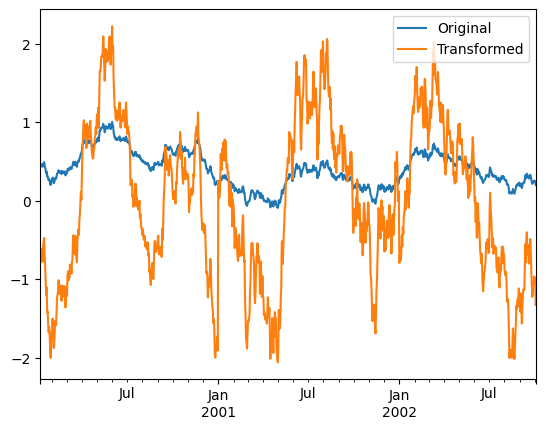

In [55]:
# We can also visually compare the original and transformed data sets.
compare = pd.DataFrame({'Original':ts, 'Transformed': transformed})
compare.plot()

In [56]:
# Transformation functions that have lower dimension outputs are broadcast to match the shape of the input array.
ts.groupby(lambda x: x.year).transform(lambda x: x.max() - x.min())

2000-01-08    0.804109
2000-01-09    0.804109
2000-01-10    0.804109
2000-01-11    0.804109
2000-01-12    0.804109
                ...   
2002-09-30    0.638336
2002-10-01    0.638336
2002-10-02    0.638336
2002-10-03    0.638336
2002-10-04    0.638336
Freq: D, Length: 1001, dtype: float64

In [57]:
# Another common data transform is to replace missing data with the group mean.
cols = ["A", "B", "C"]
values = np.random.randn(1000, 3)
values[np.random.randint(0, 1000, 100), 0] = np.nan
values[np.random.randint(0, 1000, 50), 1] = np.nan
values[np.random.randint(0, 1000, 200), 2] = np.nan
data_df = pd.DataFrame(values, columns=cols)
data_df

,A,B,C
0,1.319141,-1.600107,-1.183843
1,-0.358607,0.423049,-0.398344
2,1.724804,-0.180579,0.983033
3,-1.359538,-1.277827,-1.216960
4,0.635470,NaN,-0.569941
...,...,...,...
995,1.595310,0.434803,0.112827
996,NaN,-0.695329,-1.693956
997,1.057383,1.763923,0.402147
998,0.111250,0.506749,0.930628


In [58]:
countries = np.array(["US", "UK", "GR", "JP"])
key = countries[np.random.randint(0, 4, 1000)]
grouped = data_df.groupby(key)
# Non-NA count in each group
grouped.count()

,A,B,C
GR,231,242,214
JP,209,224,195
UK,226,239,199
US,238,246,218


In [59]:
transformed = grouped.transform(lambda x: x.fillna(x.mean()))

In [60]:
# We can verify that the group means have not changed in the transformed data, and that the transformed data contains no NAs.
grouped_trans = transformed.groupby(key)
grouped.mean()  # original group means

,A,B,C
GR,-0.041366,0.126993,-0.008424
JP,-0.039004,0.062431,-0.081610
UK,-0.019047,-0.054698,-0.057384
US,-0.075957,-0.005422,-0.186064


In [61]:
grouped_trans.mean()  # transformation did not change group means

,A,B,C
GR,-0.041366,0.126993,-0.008424
JP,-0.039004,0.062431,-0.081610
UK,-0.019047,-0.054698,-0.057384
US,-0.075957,-0.005422,-0.186064


In [62]:
grouped.count()  # original has some missing data points

,A,B,C
GR,231,242,214
JP,209,224,195
UK,226,239,199
US,238,246,218


In [63]:
grouped_trans.count()  # counts after transformation

,A,B,C
GR,254,254,254
JP,235,235,235
UK,251,251,251
US,260,260,260


In [64]:
grouped_trans.size()  # Verify non-NA count equals group size

GR    254
JP    235
UK    251
US    260
dtype: int64

In [65]:
# As mentioned in the note above, each of the examples in this section can be computed more efficiently using built-in methods. In the code below, the inefficient way using a UDF is commented out and the faster alternative appears below.
# result = ts.groupby(lambda x: x.year).transform(
#     lambda x: (x - x.mean()) / x.std()
# )
grouped = ts.groupby(lambda x: x.year)

In [66]:
result = (ts - grouped.transform("mean")) / grouped.transform("std")

In [67]:
# result = ts.groupby(lambda x: x.year).transform(lambda x: x.max() - x.min())
grouped = ts.groupby(lambda x: x.year)

In [68]:
result = grouped.transform("max") - grouped.transform("min")

In [69]:
# grouped = data_df.groupby(key)
# result = grouped.transform(lambda x: x.fillna(x.mean()))
grouped = data_df.groupby(key)

In [70]:
result = data_df.fillna(grouped.transform("mean"))

### Window and resample operations

It is possible to use `resample()`, `expanding()` and `rolling()` as methods on groupbys.

The example below will apply the `rolling()` method on the samples of the column B, based on the groups of column A.

In [71]:
df_re = pd.DataFrame({"A": [1] * 10 + [5] * 10, "B": np.arange(20)})
df_re

,A,B
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
5,1,5
6,1,6
7,1,7
8,1,8
9,1,9


In [72]:
df_re.groupby("A").rolling(4).B.mean()

A    
1  0      NaN
   1      NaN
   2      NaN
   3      1.5
   4      2.5
   5      3.5
   6      4.5
   7      5.5
   8      6.5
   9      7.5
5  10     NaN
   11     NaN
   12     NaN
   13    11.5
   14    12.5
   15    13.5
   16    14.5
   17    15.5
   18    16.5
   19    17.5
Name: B, dtype: float64

In [73]:
# The expanding() method will accumulate a given operation (sum() in the example) for all the members of each particular group.
df_re.groupby("A").expanding().sum()

B
A          
1 0     0.0
  1     1.0
  2     3.0
  3     6.0
  4    10.0
  5    15.0
  6    21.0
  7    28.0
  8    36.0
  9    45.0
5 10   10.0
  11   21.0
  12   33.0
  13   46.0
  14   60.0
  15   75.0
  16   91.0
  17  108.0
  18  126.0
  19  145.0

In [74]:
# Suppose you want to use the resample() method to get a daily frequency in each group of your dataframe, and wish to complete the missing values with the ffill() method.
df_re = pd.DataFrame(
    {
        "date": pd.date_range(start="2016-01-01", periods=4, freq="W"),
        "group": [1, 1, 2, 2],
        "val": [5, 6, 7, 8],
    }
).set_index("date")

df_re

,group,val
date,,
2016-01-03,1,5
2016-01-10,1,6
2016-01-17,2,7
2016-01-24,2,8


In [75]:
df_re.groupby("group").resample("1D").ffill()

val
group date           
1     2016-01-03    5
      2016-01-04    5
      2016-01-05    5
      2016-01-06    5
      2016-01-07    5
      2016-01-08    5
      2016-01-09    5
      2016-01-10    6
2     2016-01-17    7
      2016-01-18    7
      2016-01-19    7
      2016-01-20    7
      2016-01-21    7
      2016-01-22    7
      2016-01-23    7
      2016-01-24    8

### Filtration
A filtration is a GroupBy operation that subsets the original grouping object. It may either filter out entire groups, part of groups, or both. Filtrations return a filtered version of the calling object, including the grouping columns when provided. In the following example, class is included in the result.

In [76]:
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [77]:
speeds.groupby('class').nth(1)

,class,order,max_speed
parrot,bird,Psittaciformes,24.0
monkey,mammal,Primates,NaN


**Note**

Unlike aggregations, filtrations do not add the group keys to the index of the result. Because of this, passing `as_index=False` or `sort=True` will not affect these methods.

Filtrations will respect subsetting the columns of the GroupBy object.


In [78]:
speeds.groupby("class")[["order", "max_speed"]].nth(1)

,order,max_speed
parrot,Psittaciformes,24.0
monkey,Primates,NaN


 **Built-in filtrations**

The following methods on GroupBy act as filtrations. All these methods have an efficient, GroupBy-specific, implementation.

| Method       | Description                            |
| ------------ | -------------------------------------- |
| **`head()`** | Select the top row(s) of each group    |
| **`nth()`**  | Select the nth row(s) of each group    |
| **`tail()`** | Select the bottom row(s) of each group |

Users can also use transformations along with Boolean indexing to construct complex filtrations within groups. For example, suppose we are given groups of products and their volumes, and we wish to subset the data to only the largest products capturing no more than 90% of the total volume within each group.


In [79]:
product_volumes = pd.DataFrame(
    {
        "group": list("xxxxyyy"),
        "product": list("abcdefg"),
        "volume": [10, 30, 20, 15, 40, 10, 20],
    }
)
product_volumes

,group,product,volume
0,x,a,10
1,x,b,30
2,x,c,20
3,x,d,15
4,y,e,40
5,y,f,10
6,y,g,20


In [80]:
# Sort by volume to select the largest products first
product_volumes = product_volumes.sort_values("volume", ascending=False)
grouped = product_volumes.groupby("group")["volume"]
cumpct = grouped.cumsum() / grouped.transform("sum")
cumpct

4    0.571429
1    0.400000
2    0.666667
6    0.857143
3    0.866667
0    1.000000
5    1.000000
Name: volume, dtype: float64

In [81]:
significant_products = product_volumes[cumpct <= 0.9]
significant_products.sort_values(["group", "product"])

,group,product,volume
1,x,b,30
2,x,c,20
3,x,d,15
4,y,e,40
6,y,g,20


## Flexible `apply`

Some operations on the grouped data might not fit into the aggregation, transformation, or filtration categories. For these, you can use the `apply` function.

##### ⚠️ Warning

`apply` has to try to infer from the result whether it should act as a reducer, transformer, *or* filter, depending on exactly what is passed to it. Thus the grouped column(s) may be included in the output or not. While it tries to intelligently guess how to behave, it can sometimes guess wrong.

**Note**

All of the examples in this section can be more reliably, and more efficiently, computed using other pandas functionality.


In [82]:
df

,A,B,C,D
0,foo,one,-1.013053,0.143497
1,bar,one,1.329097,0.405837
2,foo,two,-1.008103,0.129290
3,bar,three,-1.309196,-1.112608
4,foo,two,-0.672255,0.750958
5,bar,two,-1.095771,0.535120
6,foo,one,0.128034,0.525644
7,foo,three,1.918012,-0.757675


In [83]:
grouped = df.groupby('A')

In [84]:
# could also just call .describe()
grouped['C'].apply(lambda x: x.describe())

A         
bar  count    3.000000
     mean    -0.358623
     std      1.465499
     min     -1.309196
     25%     -1.202483
     50%     -1.095771
     75%      0.116663
     max      1.329097
foo  count    5.000000
     mean    -0.129473
     std      1.235498
     min     -1.013053
     25%     -1.008103
     50%     -0.672255
     75%      0.128034
     max      1.918012
Name: C, dtype: float64

In [85]:
# The dimension of the returned result can also change:
grouped = df.groupby('A')['C']
def f(group):
    return pd.DataFrame({'original': group,
                         'demeaned': group - group.mean()})

grouped.apply(f)

original  demeaned
A                        
bar 1  1.329097  1.687720
    3 -1.309196 -0.950572
    5 -1.095771 -0.737148
foo 0 -1.013053 -0.883580
    2 -1.008103 -0.878630
    4 -0.672255 -0.542782
    6  0.128034  0.257507
    7  1.918012  2.047485

In [86]:
# apply on a Series can operate on a returned value from the applied function that is itself a series, and possibly upcast the result to a DataFrame:

def f(x):
    return pd.Series([x, x ** 2], index=["x", "x^2"])

s = pd.Series(np.random.rand(5))
s

0    0.625446
1    0.466615
2    0.511542
3    0.718787
4    0.042759
dtype: float64

In [87]:
s.apply(f)

,x,x^2
0,0.625446,0.391183
1,0.466615,0.217729
2,0.511542,0.261675
3,0.718787,0.516654
4,0.042759,0.001828


In [88]:
# Similar to The aggregate() method, the resulting dtype will reflect that of the apply function. If the results from different groups have different dtypes, then a common dtype will be determined in the same way as DataFrame construction.

### Handling of (un)observed Categorical values

When using a `Categorical` grouper (as a single grouper, or as part of multiple groupers), the `observed` keyword controls whether to return a cartesian product of all possible groupers values (`observed=False`) or only those that are observed groupers (`observed=True`).

Show all values:


In [89]:
pd.Series([1, 1, 1]).groupby(
    pd.Categorical(["a", "a", "a"], categories=["a", "b"]), observed=False
).count()

a    3
b    0
dtype: int64

In [90]:
# Show only the observed values:

pd.Series([1, 1, 1]).groupby(
    pd.Categorical(["a", "a", "a"], categories=["a", "b"]), observed=True
).count()

a    3
dtype: int64

In [91]:
# The returned dtype of the grouped will always include all of the categories that were grouped.

s = (
    pd.Series([1, 1, 1])
    .groupby(pd.Categorical(["a", "a", "a"], categories=["a", "b"]), observed=True)
    .count()
)


s.index.dtype

CategoricalDtype(categories=['a', 'b'], ordered=False, categories_dtype=str)

### Taking the first rows of each group

In [92]:
# Just like for a DataFrame or Series you can call head and tail on a groupby:

df = pd.DataFrame([[1, 2], [1, 4], [5, 6]], columns=["A", "B"])
df

,A,B
0,1,2
1,1,4
2,5,6


In [93]:
g = df.groupby('A')
g.head(1)

,A,B
0,1,2
2,5,6


In [94]:
g.tail(1)

,A,B
1,1,4
2,5,6
